In [3]:
# ============================================================
# DAY 9 — GOOGLE DRIVE MOUNT CHECK
# ============================================================

from google.colab import drive
from pathlib import Path

print("=" * 60)
print("MOUNTING GOOGLE DRIVE")
print("=" * 60)

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/MediScan")

print("\nProject directory:")
print(PROJECT_DIR)

print("\nProject directory exists:", PROJECT_DIR.exists())

if PROJECT_DIR.exists():
    print("\nContents of MediScan:")
    for item in PROJECT_DIR.iterdir():
        print("→", item.name)
else:
    print("\n❌ MediScan project directory not found!")

print("=" * 60)

MOUNTING GOOGLE DRIVE
Mounted at /content/drive

Project directory:
/content/drive/MyDrive/MediScan

Project directory exists: True

Contents of MediScan:
→ data
→ figures
→ reports
→ models


In [4]:
# ============================================================
# DAY 9 — CHECK MODEL CHECKPOINT
# ============================================================

from pathlib import Path

MODEL_DIR = Path("/content/drive/MyDrive/MediScan/models")

print("=" * 60)
print("CHECKING MODEL DIRECTORY")
print("=" * 60)

print("\nModels directory exists:", MODEL_DIR.exists())

print("\nFiles inside models/:")

files = list(MODEL_DIR.iterdir())

if files:
    for file in files:
        print("→", file.name)
else:
    print("❌ Models folder is empty!")

print("=" * 60)

CHECKING MODEL DIRECTORY

Models directory exists: True

Files inside models/:
→ efficientnet_b0_best_day7.pth
→ efficientnet_b0_best_day8.pth


In [5]:
# ============================================================
# DAY 9 — LOAD BEST DAY 8 MODEL
# ============================================================

import torch
import torch.nn as nn
from torchvision import models
from pathlib import Path

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROJECT_DIR = Path("/content/drive/MyDrive/MediScan")
MODEL_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"
FIGURES_DIR = PROJECT_DIR / "figures"

BEST_MODEL_PATH = MODEL_DIR / "efficientnet_b0_best_day8.pth"

print("=" * 60)
print("DAY 9 — LOADING BEST DAY 8 MODEL")
print("=" * 60)

print("Device:", DEVICE)
print("Model:", BEST_MODEL_PATH)

# Load checkpoint
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

print("\n✅ Checkpoint loaded successfully!")

# Class mapping
class_to_idx = checkpoint["class_to_idx"]
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Recreate model
model = models.efficientnet_b0(weights=None)

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=checkpoint["dropout"]),
    nn.Linear(num_features, checkpoint["num_classes"])
)

model.load_state_dict(checkpoint["model_state_dict"])

model = model.to(DEVICE)
model.eval()

print("\nModel configuration:")
print("Architecture :", checkpoint["architecture"])
print("Classes      :", checkpoint["num_classes"])
print("Dropout      :", checkpoint["dropout"])
print("Learning Rate:", checkpoint["learning_rate"])
print("Batch Size   :", checkpoint["batch_size"])
print("Augmentation :", checkpoint["augmentation"])

print("\nClass mapping:")
print(class_to_idx)

print("\n✅ Model ready for Day 9 evaluation!")
print("=" * 60)

DAY 9 — LOADING BEST DAY 8 MODEL
Device: cuda
Model: /content/drive/MyDrive/MediScan/models/efficientnet_b0_best_day8.pth

✅ Checkpoint loaded successfully!

Model configuration:
Architecture : EfficientNet-B0
Classes      : 4
Dropout      : 0.1
Learning Rate: 0.002
Batch Size   : 32
Augmentation : weak

Class mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

✅ Model ready for Day 9 evaluation!


In [8]:
# ============================================================
# DAY 9 — RESTORE TORCHVISION TRANSFORMS
# ============================================================

import torch
from torchvision import transforms

print("✅ torchvision.transforms restored!")

✅ torchvision.transforms restored!


In [12]:
# ============================================================
# DAY 9 — RESTORE LOCAL RAW DATASET
# ============================================================

from pathlib import Path
import shutil

DRIVE_RAW_DIR = Path("/content/drive/MyDrive/MediScan/data/raw")
LOCAL_RAW_DIR = Path("/content/MediScan/data/raw")

print("=" * 60)
print("RESTORING LOCAL RAW DATASET")
print("=" * 60)

print("\nDrive raw dataset:", DRIVE_RAW_DIR)
print("Exists:", DRIVE_RAW_DIR.exists())

if not DRIVE_RAW_DIR.exists():
    raise FileNotFoundError(
        f"Drive raw dataset not found: {DRIVE_RAW_DIR}"
    )

# Create local directory
LOCAL_RAW_DIR.parent.mkdir(parents=True, exist_ok=True)

# Copy dataset
if LOCAL_RAW_DIR.exists():
    print("\nLocal directory already exists.")
else:
    print("\nCopying raw dataset from Drive to local runtime...")
    shutil.copytree(DRIVE_RAW_DIR, LOCAL_RAW_DIR)

# Count images
image_extensions = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

image_count = sum(
    1 for p in LOCAL_RAW_DIR.rglob("*")
    if p.is_file() and p.suffix in image_extensions
)

print("\nLocal raw directory:", LOCAL_RAW_DIR)
print("Exists:", LOCAL_RAW_DIR.exists())
print("Images found:", image_count)

print("\n" + "=" * 60)

if image_count == 7200:
    print("✅ All 7200 raw images restored successfully!")
else:
    print(f"⚠️ Found {image_count} images. Expected 7200.")

print("=" * 60)

RESTORING LOCAL RAW DATASET

Drive raw dataset: /content/drive/MyDrive/MediScan/data/raw
Exists: True

Copying raw dataset from Drive to local runtime...

Local raw directory: /content/MediScan/data/raw
Exists: True
Images found: 7200

✅ All 7200 raw images restored successfully!


In [13]:
# ============================================================
# DAY 9 — RECREATE TEST DATASET & DATALOADER
# ============================================================

test_df = pd.read_csv(TEST_CSV)

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dataset = BrainMRIDataset(
    dataframe=test_df,
    transform=eval_transform,
    class_to_idx=class_to_idx,
    local_raw_dir=LOCAL_RAW_DIR
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2
)

print("=" * 60)
print("TEST DATALOADER VERIFICATION")
print("=" * 60)

print("Test dataset size :", len(test_dataset))
print("Test loader batches:", len(test_loader))
print("Batch size        :", test_loader.batch_size)

test_images, test_labels = next(iter(test_loader))

print("\nBatch verification:")
print("Images shape :", test_images.shape)
print("Labels shape :", test_labels.shape)
print("Images dtype :", test_images.dtype)
print("Labels dtype :", test_labels.dtype)

print("\nUnique labels in batch:")
print(torch.unique(test_labels).tolist())

print("=" * 60)

TEST DATALOADER VERIFICATION
Test dataset size : 1080
Test loader batches: 34
Batch size        : 32

Batch verification:
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Images dtype : torch.float32
Labels dtype : torch.int64

Unique labels in batch:
[0, 1, 2, 3]


In [14]:
# ============================================================
# DAY 9 — GENERATE TEST SET PREDICTIONS
# ============================================================

import numpy as np
import torch

print("=" * 60)
print("DAY 9 — TEST SET INFERENCE")
print("=" * 60)

model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        # Forward pass
        outputs = model(images)

        # Convert logits to probabilities
        probabilities = torch.softmax(outputs, dim=1)

        # Predicted class
        predictions = torch.argmax(probabilities, dim=1)

        # Store results on CPU
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())
        y_prob.extend(probabilities.cpu().numpy())

        if (batch_idx + 1) % 10 == 0:
            print(
                f"Processed batches: "
                f"{batch_idx + 1}/{len(test_loader)}"
            )

# Convert to NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("\n" + "=" * 60)
print("INFERENCE COMPLETED")
print("=" * 60)

print("True labels shape :", y_true.shape)
print("Predictions shape :", y_pred.shape)
print("Probabilities shape:", y_prob.shape)

print("\nExpected:")
print("True labels       : (1080,)")
print("Predictions       : (1080,)")
print("Probabilities     : (1080, 4)")

print("\nNumber of predictions:", len(y_pred))

print("=" * 60)

DAY 9 — TEST SET INFERENCE
Processed batches: 10/34
Processed batches: 20/34
Processed batches: 30/34

INFERENCE COMPLETED
True labels shape : (1080,)
Predictions shape : (1080,)
Probabilities shape: (1080, 4)

Expected:
True labels       : (1080,)
Predictions       : (1080,)
Probabilities     : (1080, 4)

Number of predictions: 1080


In [15]:
# ============================================================
# DAY 9 — CLASSIFICATION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("=" * 60)
print("DAY 9 — MODEL EVALUATION METRICS")
print("=" * 60)

# ------------------------------------------------------------
# Overall metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\nOverall Test Metrics:")
print(f"Accuracy  : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# ------------------------------------------------------------
# Per-class classification report
# ------------------------------------------------------------

target_names = [
    idx_to_class[i]
    for i in range(len(idx_to_class))
]

print("\n" + "=" * 60)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 60)

report = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    digits=4,
    zero_division=0
)

print(report)

print("=" * 60)

DAY 9 — MODEL EVALUATION METRICS

Overall Test Metrics:
Accuracy  : 0.9120 (91.20%)
Precision : 0.9132
Recall    : 0.9120
F1-Score  : 0.9116

PER-CLASS CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma     0.9458    0.8407    0.8902       270
  meningioma     0.8423    0.8704    0.8561       270
     notumor     0.9301    0.9852    0.9568       270
   pituitary     0.9345    0.9519    0.9431       270

    accuracy                         0.9120      1080
   macro avg     0.9132    0.9120    0.9116      1080
weighted avg     0.9132    0.9120    0.9116      1080



DAY 9 — CONFUSION MATRIX

Confusion Matrix:
[[227  33   8   2]
 [ 13 235   7  15]
 [  0   3 266   1]
 [  0   8   5 257]]


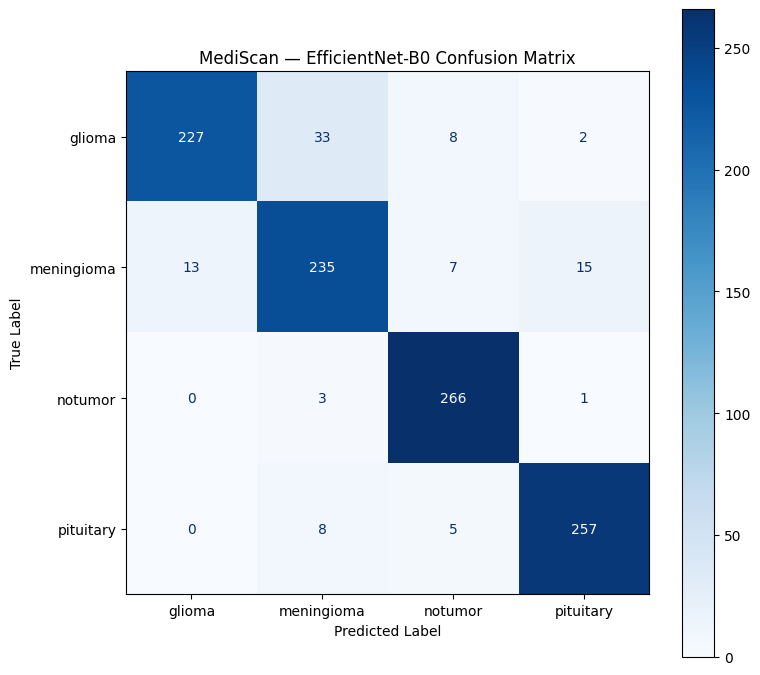


✅ Confusion matrix saved:
/content/drive/MyDrive/MediScan/figures/day9_confusion_matrix.png


In [16]:
# ============================================================
# DAY 9 — CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("=" * 60)
print("DAY 9 — CONFUSION MATRIX")
print("=" * 60)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Display confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_title("MediScan — EfficientNet-B0 Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()

# Save figure
cm_path = FIGURES_DIR / "day9_confusion_matrix.png"

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ Confusion matrix saved:")
print(cm_path)

print("=" * 60)

DAY 9 — ROC CURVES


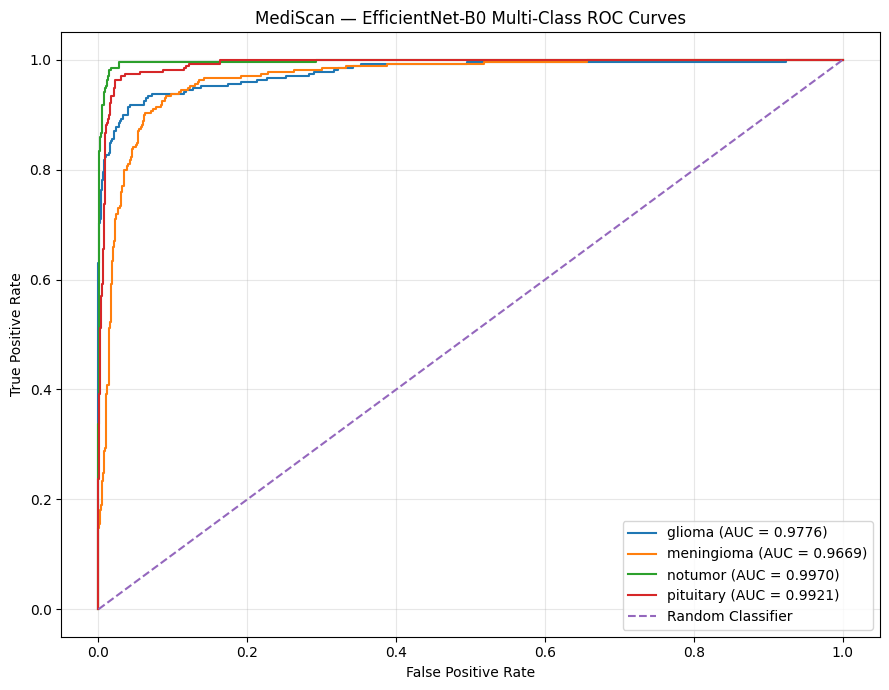


Per-class ROC-AUC:
glioma      : 0.9776
meningioma  : 0.9669
notumor     : 0.9970
pituitary   : 0.9921

✅ ROC curves saved:
/content/drive/MyDrive/MediScan/figures/day9_roc_curves.png


In [17]:
# ============================================================
# DAY 9 — MULTI-CLASS ROC CURVES
# ============================================================

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

print("=" * 60)
print("DAY 9 — ROC CURVES")
print("=" * 60)

# ------------------------------------------------------------
# Binarize true labels for multi-class ROC
# ------------------------------------------------------------

n_classes = len(target_names)

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(n_classes)
)

# ------------------------------------------------------------
# Calculate ROC curve and AUC for each class
# ------------------------------------------------------------

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

# ------------------------------------------------------------
# Plot ROC curves
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{target_names[i]} (AUC = {roc_auc[i]:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MediScan — EfficientNet-B0 Multi-Class ROC Curves")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

roc_path = FIGURES_DIR / "day9_roc_curves.png"

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Print AUC
# ------------------------------------------------------------

print("\nPer-class ROC-AUC:")

for i in range(n_classes):
    print(
        f"{target_names[i]:12s}: "
        f"{roc_auc[i]:.4f}"
    )

print("\n✅ ROC curves saved:")
print(roc_path)

print("=" * 60)

In [19]:
# Define class names for Day 9 evaluation
class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

print("Class names:", class_names)

Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [20]:
# Day 9 — Save Evaluation Metrics
# ==========================================

from pathlib import Path
import pandas as pd
import json

REPORTS_DIR = Path("/content/drive/MyDrive/MediScan/reports")
FIGURES_DIR = Path("/content/drive/MyDrive/MediScan/figures")

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Classification report dictionary
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

# Save classification report
classification_df = pd.DataFrame(report_dict).transpose()
classification_df.to_csv(
    REPORTS_DIR / "day9_classification_report.csv"
)

# ROC-AUC results
roc_auc_results = {}

for i, class_name in enumerate(class_names):
    y_true_binary = (y_true == i).astype(int)
    fpr, tpr, _ = roc_curve(y_true_binary, y_prob[:, i])
    roc_auc_results[class_name] = float(auc(fpr, tpr))

roc_auc_df = pd.DataFrame(
    list(roc_auc_results.items()),
    columns=["class", "roc_auc"]
)

roc_auc_df.to_csv(
    REPORTS_DIR / "day9_roc_auc.csv",
    index=False
)

# Overall metrics
overall_metrics = {
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "weighted_precision": float(
        classification_report(
            y_true, y_pred,
            target_names=class_names,
            output_dict=True
        )["weighted avg"]["precision"]
    ),
    "weighted_recall": float(
        classification_report(
            y_true, y_pred,
            target_names=class_names,
            output_dict=True
        )["weighted avg"]["recall"]
    ),
    "weighted_f1": float(
        classification_report(
            y_true, y_pred,
            target_names=class_names,
            output_dict=True
        )["weighted avg"]["f1-score"]
    ),
    "roc_auc": roc_auc_results
}

with open(
    REPORTS_DIR / "day9_evaluation_metrics.json",
    "w"
) as f:
    json.dump(overall_metrics, f, indent=4)

print("Day 9 evaluation artifacts saved successfully.")
print("=" * 50)

print("Classification report:")
print(REPORTS_DIR / "day9_classification_report.csv")

print("\nROC-AUC report:")
print(REPORTS_DIR / "day9_roc_auc.csv")

print("\nOverall metrics:")
print(REPORTS_DIR / "day9_evaluation_metrics.json")

print("\nFigures:")
print(FIGURES_DIR / "day9_confusion_matrix.png")
print(FIGURES_DIR / "day9_roc_curves.png")

Day 9 evaluation artifacts saved successfully.
Classification report:
/content/drive/MyDrive/MediScan/reports/day9_classification_report.csv

ROC-AUC report:
/content/drive/MyDrive/MediScan/reports/day9_roc_auc.csv

Overall metrics:
/content/drive/MyDrive/MediScan/reports/day9_evaluation_metrics.json

Figures:
/content/drive/MyDrive/MediScan/figures/day9_confusion_matrix.png
/content/drive/MyDrive/MediScan/figures/day9_roc_curves.png


In [21]:
# Day 9 — Final Evaluation Summary
# ==========================================

from pathlib import Path

REPORTS_DIR = Path("/content/drive/MyDrive/MediScan/reports")

summary_text = """
# MediScan — Day 9 Evaluation Summary

## Objective

Evaluate the trained EfficientNet-B0 model on the held-out test set using
classification metrics, confusion matrix, and multi-class ROC-AUC analysis.

## Test Dataset

- Total test images: 1080
- Classes: 4
- Images per class: 270
- Test set was not used during hyperparameter tuning.

## Overall Performance

| Metric | Score |
|---|---:|
| Accuracy | 91.20% |
| Weighted Precision | 91.32% |
| Weighted Recall | 91.20% |
| Weighted F1-score | 91.16% |

## Per-Class Performance

| Class | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Glioma | 94.58% | 84.07% | 89.02% |
| Meningioma | 84.23% | 87.04% | 85.61% |
| No Tumor | 93.01% | 98.52% | 95.68% |
| Pituitary | 93.45% | 95.19% | 94.31% |

## Confusion Matrix

The confusion matrix was generated and saved as:

`figures/day9_confusion_matrix.png`

Confusion matrix:

| Actual \\ Predicted | Glioma | Meningioma | No Tumor | Pituitary |
|---|---:|---:|---:|---:|
| Glioma | 227 | 33 | 8 | 2 |
| Meningioma | 13 | 235 | 7 | 15 |
| No Tumor | 0 | 3 | 266 | 1 |
| Pituitary | 0 | 8 | 5 | 257 |

## ROC-AUC Analysis

| Class | ROC-AUC |
|---|---:|
| Glioma | 0.9776 |
| Meningioma | 0.9669 |
| No Tumor | 0.9970 |
| Pituitary | 0.9921 |

ROC curves were generated and saved as:

`figures/day9_roc_curves.png`

## Observations

- The model achieved 91.20% accuracy on the unseen test set.
- No Tumor achieved the strongest classification performance with an F1-score
  of 95.68% and ROC-AUC of 0.9970.
- Pituitary also showed strong performance with an F1-score of 94.31%.
- Glioma had high precision (94.58%) but comparatively lower recall (84.07%).
- Meningioma was the most challenging class based on F1-score (85.61%).
- All four classes achieved ROC-AUC values above 0.96, indicating strong
  class-separation capability.

## Day 9 Conclusion

The EfficientNet-B0 model demonstrated strong generalization on the held-out
test set, achieving 91.20% accuracy and a weighted F1-score of 91.16%.

The evaluation confirms that the optimized Day 8 configuration performs well
on unseen MRI images. The test set remained untouched during hyperparameter
tuning, providing an independent evaluation of the final model.

## Saved Artifacts

- `reports/day9_classification_report.csv`
- `reports/day9_roc_auc.csv`
- `reports/day9_evaluation_metrics.json`
- `reports/day9_summary.md`
- `figures/day9_confusion_matrix.png`
- `figures/day9_roc_curves.png`
"""

summary_path = REPORTS_DIR / "day9_summary.md"

with open(summary_path, "w") as f:
    f.write(summary_text.strip())

print("Day 9 summary saved successfully.")
print("=" * 50)
print(summary_path)

Day 9 summary saved successfully.
/content/drive/MyDrive/MediScan/reports/day9_summary.md
